In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from plotly.express import scatter, pie
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
import seaborn as sns

In [4]:
df = pd.read_csv(r"C:\Users\selva\Desktop\Tumo Labs\Station project 1 - ML\Tips\data\tips.csv")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [5]:
# check for null values 
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [6]:
print('day' in df.columns)
print('time' in df.columns)

df[['day', 'time']]

True
True


,day,time
0,Sun,Dinner
1,Sun,Dinner
2,Sun,Dinner
3,Sun,Dinner
4,Sun,Dinner
...,...,...
239,Sat,Dinner
240,Sat,Dinner
241,Sat,Dinner
242,Sat,Dinner


In [9]:
# converting to numeric vals
df['sex'] = df['sex'].map({'Male': 0, 'Female': 1})
df['smoker'] = df['smoker'].map({'No': 0, 'Yes': 1})
df = pd.get_dummies(df, columns=['day', 'time'], drop_first=True)

In [10]:
df.head()

,total_bill,tip,sex,smoker,size,day_Sat,day_Sun,day_Thur,time_Lunch
0,16.99,1.01,1,0,2,False,True,False,False
1,10.34,1.66,0,0,3,False,True,False,False
2,21.01,3.50,0,0,3,False,True,False,False
3,23.68,3.31,0,0,2,False,True,False,False
4,24.59,3.61,1,0,4,False,True,False,False


In [17]:
# features 
X = df.drop('tip', axis=1)
y = df['tip']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
# train 
model = linear_model.LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
# test
score = model.score(X_test, y_test)
print(f"Model Score: {score}")

Model Score: 0.4373018194348246


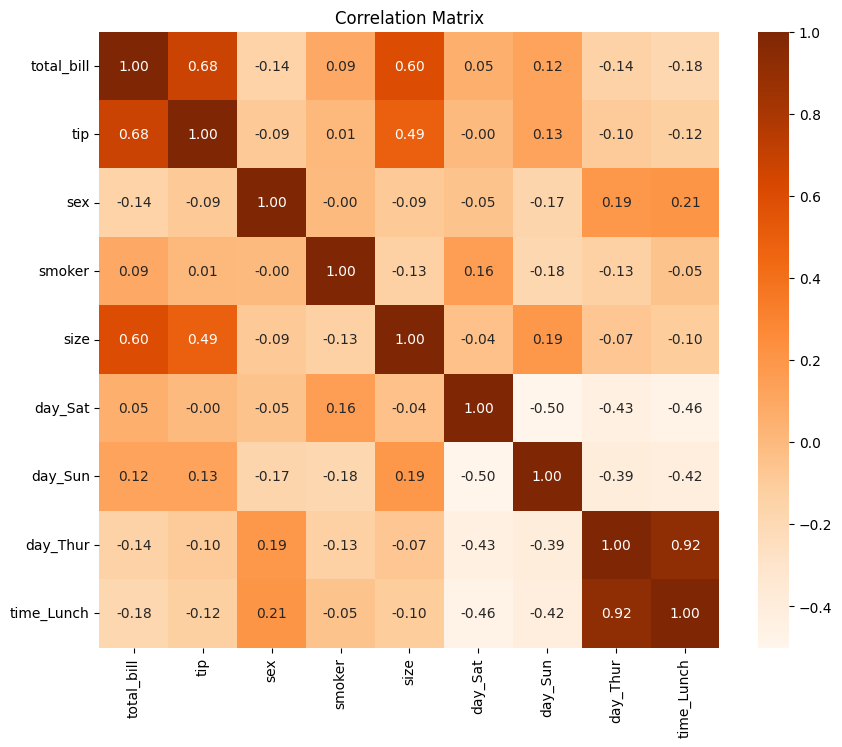

In [14]:
corr = df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='Oranges', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()